In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, aberration, equatorial2galactic, galactic2equatorial
import os
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
sim = Simulation("StellarVariability")
switchOffAllEffects(sim)
sim["ObservingParameters/NumExposures"] = 100
workDir = os.environ["PLATO_WORKDIR"]
sim.outputDir = workDir

position = 4000
dim = 100
numSubPixels = sim["SubField/SubPixels"]

sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 4510

# Variability

magnitude = 12.5
starCatalogFilename = workDir + "generatedFromPixelCoordinates.starcat"
sim.createStarCatalogFileFromPixelCoordinates(np.array([position]), np.array([position]), np.array([magnitude]), np.array([1]), starCatalogFilename)
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

variabilityFilename = workDir + "variability.txt"

cycleTime = sim["ObservingParameters/CycleTime"]
period = 20 * cycleTime
time = np.arange(3000.)
sin = np.sin(2 * math.pi / period * time)

myFile = open(variabilityFilename, "w")
for n in range(len(time)):
    myFile.write("{0}  {1}\n".format(time[n], sin[n]))
myFile.close()

varsourceFilename = workDir + "varsource.txt"

myFile = open(varsourceFilename, "w")
myFile.write("{0}  {1}\n".format(1, variabilityFilename))
myFile.close()

sim["Sky/VariableSourceList"] = varsourceFilename
sim["Sky/IncludeVariableSources"] = "yes"

sim["SubField/ZeroPointRow"] = position - dim // 2
sim["SubField/ZeroPointColumn"] = position - dim // 2
sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim

output = sim.run(removeOutputFile = True)

Text(0, 0.5, '$\\Delta m$')

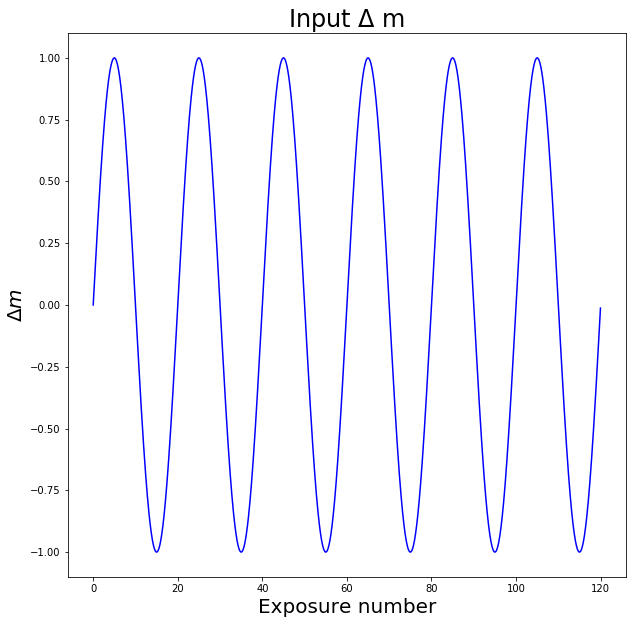

In [3]:
fig = plt.figure(figsize = (10, 10))

plt.plot(time / cycleTime, sin, "b")
plt.title("Input $\Delta$ m", fontsize=24)
plt.xlabel("Exposure number", fontsize=20)
plt.ylabel("$\Delta m$", fontsize=20)

In [4]:
inputMagnitudes = sin + magnitude

In [5]:
exposureTime = cycleTime - sim.getReadoutTime()[0]

fluxes = np.array([])

for exposure in range(sim["ObservingParameters/NumExposures"]):
    
    ID, rows, columns, Xmm, Ymm, flux = output.getStarCoordinates(exposure)
    fluxes = np.append(fluxes, flux)     # [photons]

outputMagnitudes = -2.5 * np.log10(fluxes / (exposureTime * sim["ObservingParameters/Fluxm0"] * sim["Camera/ThroughputBandwidth"] * sim["Telescope/LightCollectingArea"] * sim["Telescope/TransmissionEfficiency/BOL"] * 1E-4))

(11.0, 14.0)

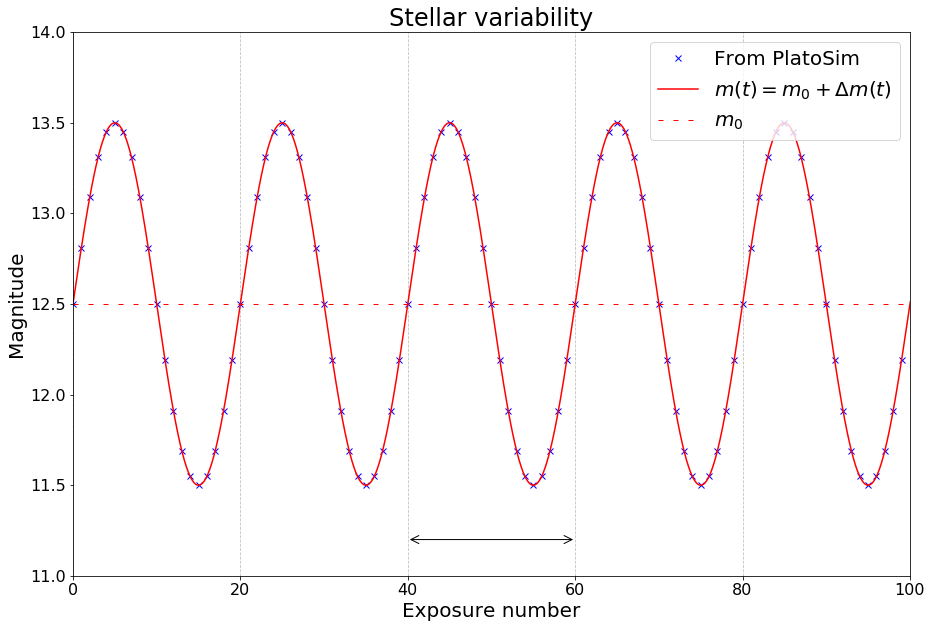

In [23]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(outputMagnitudes, "bx", label="From PlatoSim")



########
# Theory
########

exposureTime = cycleTime - sim.getReadoutTime()[0]
plt.plot(time / cycleTime, inputMagnitudes, "r", label="$m(t) = m_0 + \Delta m(t)}$" )
plt.axhline(y = magnitude, color = "r", linestyle=(0, (5, 10)), linewidth=1, label = "$m_0$")

plt.grid(color = "gray", axis="x", linestyle="--", alpha=0.5)



########
# Layout
########

plt.annotate(s='', xy=(40, 11.2), xytext=(60, 11.2), arrowprops=dict(arrowstyle='<->'), fontsize=20)

plt.title("Stellar variability", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Magnitude", fontsize = 20)
plt.xlim([0, 100])
plt.ylim([magnitude - 1.5, magnitude + 1.5])